In [7]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import (train_test_split)

from sklearn.preprocessing import (LabelEncoder)

from sklearn.ensemble import (RandomForestRegressor)

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [8]:
# Load dataset
DATA_PATH = Path(
    "../data/processed/pairwise_engineered.csv"
)

df = pd.read_csv(DATA_PATH)

print("DATASET SHAPE\n")

print(df.shape)

df.head()

DATASET SHAPE

(10000, 150)


,student_id_1,lifestyle_type_1,age_1,gender_1,course_1,year_of_study_1,hostel_block_1,sleep_time_1,wake_time_1,alarm_count_1,...,gaming_hours_similarity,guest_frequency_similarity,noise_sleep_tolerance_similarity,sleep_compatibility,study_compatibility,cleanliness_compatibility,social_compatibility,privacy_compatibility,same_lifestyle_type,behavioral_alignment_score
0,204,social,23,Male,BCOM,2,A,23,7,2,...,0.875,0.50,1.00,0.083333,0.833333,0.75,0.583333,1.00,0,0.650000
1,461,night_owl,18,Male,BCOM,2,A,3,9,5,...,0.875,0.50,0.75,0.125000,0.666667,1.00,0.750000,0.75,0,0.658333
2,403,average,18,Female,BBA,4,A,22,6,2,...,1.000,0.75,0.50,0.041667,0.833333,0.50,0.666667,1.00,1,0.608333
3,227,social,21,Male,BCOM,3,C,1,8,5,...,0.875,0.75,1.00,0.125000,0.500000,0.75,0.750000,0.75,0,0.575000
4,348,disciplined,20,Male,ME,4,A,23,5,3,...,0.875,1.00,0.75,-0.083333,0.833333,1.00,0.833333,0.50,0,0.616667


In [11]:
# Encode categorical features
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index([], dtype='str')


In [12]:
# One-Hot Encoding 
# The categorical variables in the roommate compatibility dataset were nominal and 
# had no inherent ordering. One-Hot Encoding preserves category independence 
# and prevents the model from learning artificial ordinal relationships that can 
# arise with Label Encoding.
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=False
)

<Axes: >

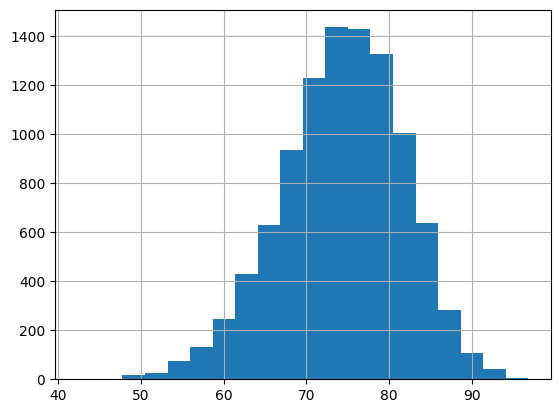

In [30]:
df["compatibility_score"].describe()
df["compatibility_score"].hist(bins=20)

In [31]:
df["compatibility_score"].quantile(
    [0.33, 0.66]
)

0.33    71.48
0.66    77.78
Name: compatibility_score, dtype: float64

In [32]:
# Creating classification labels
def classify_compatibility(score):

    if score < 71.48:
        return "Low"

    elif score < 77.78:
        return "Medium"

    else:
        return "High"

In [33]:
df["compatibility_label"] = (df["compatibility_score"].apply(classify_compatibility))

In [34]:
df["compatibility_label"].value_counts()

compatibility_label
High      3409
Medium    3299
Low       3292
Name: count, dtype: int64

In [35]:
X_classification = df.drop(
    columns=[
        "compatibility_score",
        "compatibility_label"])

y_classification = df["compatibility_label"]

In [36]:
X_train, X_test, y_train, y_test = (
    train_test_split(

        X_classification,
        y_classification,
        test_size=0.2,
        random_state=42
    )
)

In [37]:
# Train Random Forest Classifier
from sklearn.ensemble import (
    RandomForestClassifier
)
classifier = RandomForestClassifier(

    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

classifier.fit(
    X_train,
    y_train
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [40]:
# Predictions
classification_predictions = (classifier.predict(X_test))

In [41]:
# Metrics
from sklearn.metrics import (

    accuracy_score,
    classification_report,
    f1_score
)

In [42]:
accuracy = accuracy_score(

    y_test,
    classification_predictions
)

f1 = f1_score(

    y_test,
    classification_predictions,
    average="weighted"
)

In [44]:
print("CLASSIFICATION PERFORMANCE\n")

print(f"Accuracy : {accuracy:.3f}")

print(f"F1 Score : {f1:.3f}")

CLASSIFICATION PERFORMANCE

Accuracy : 0.757
F1 Score : 0.754


In [45]:
print(

    classification_report(
        y_test,
        classification_predictions
    )
)

              precision    recall  f1-score   support

        High       0.77      0.84      0.81       644
         Low       0.82      0.84      0.83       663
      Medium       0.67      0.60      0.63       693

    accuracy                           0.76      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.75      0.76      0.75      2000

